<div style="background: #1f2933; padding: 30px; border-radius: 14px; text-align: center; color: #f9fafb; box-shadow: 0px 4px 12px rgba(0,0,0,0.15); border-left: 5px solid #f59e0b;">

<h1 style="margin-bottom: 10px;">
📊 Exercise Project 1 – Linear Regression
</h1>

<h3 style="margin-top: 0; font-weight: 400; color: #fde68a;">
ML Model: Car Price Dataset with Missing Values
</h3>

</div>

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #f59e0b; width: fit-content;">

<h4 style="margin:0; color:#f9fafb;">
<b>Dataset name:</b>
</h4>

<a href="https://www.kaggle.com/code/alexmoreau/feature-importance-analysis/input" 
   target="_blank"
   style="font-size:16px; color:#fde68a; text-decoration:none;">
Car Price Prediction Dataset With Missing Values
</a>

</div>


<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #f59e0b; width: fit-content;">

<h4 style="margin:0; color:#f9fafb;">
<b>Dataset format:</b>
</h4>

<p style="font-size:16px; color:#fde68a; text-decoration:none;">
    Single CSV
</p>

</div>


<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #f59e0b; width: fit-content;">

  <h4 style="margin:0; color:#f9fafb;">
    <b>Data description, features and limitations</b>
  </h4>

  <p style="margin:10px 0 6px 0; font-size:16px; color:#fde68a;">
    <b>Description:</b><br/>
    This is an automobile dataset designed for car price prediction using machine learning. It contains structured
    information about vehicles with various attributes that influence pricing.
  </p>

  <p style="margin:10px 0 6px 0; font-size:16px; color:#fde68a;">
    <b>Features:</b><br/>
    The dataset includes the following attributes:
  </p>

  <ul style="margin:6px 0 0 18px; padding:0; font-size:16px; color:#fde68a;">
    <li><b>Brand</b> – Car manufacturer</li>
    <li><b>Model</b> – Specific vehicle model</li>
    <li><b>Year</b> – Manufacturing year</li>
    <li><b>Engine specifications</b> – Technical details about the engine</li>
    <li><b>Mileage</b> – Distance traveled by the vehicle</li>
    <li><b>Condition</b> – Physical/functional state of the car</li>
    <li><b>Price</b> – Target variable (what you’re predicting)</li>
  </ul>

</div>


<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #f59e0b; width: fit-content;">

  <h4 style="margin:0; color:#f9fafb;">
    <b>Note:</b>
  </h4>

  <p style="margin:8px 0 0 0; font-size:16px; color:#fde68a; line-height:1.5;">
    This dataset is almost the same as Notebook 1, but this version includes <b>NaN</b> (missing) values.
  </p>

</div>


<div style="background-color: #fff3cd; border: 2px solid #ffc107; padding: 15px; border-radius: 8px; margin: 20px 0;">
    <h3 style="color: #856404; margin-top: 0;">⚠️ Before You Start</h3>
    <p style="color: #856404; margin-bottom: 0;">
        <strong>Remember:</strong> Run each cell in order by clicking inside it and pressing <kbd>Shift</kbd> + <kbd>Enter</kbd>. Don't skip ahead!
    </p>
</div>

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #f59e0b; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b>STEP 1 - Loading the dataset</b>
</h3>
<p style="font-size:16px; color:#fde68a; text-decoration:none;">
    Code: Importing modules, custom functions and loading the data
</p>
</div>


In [148]:
# Loading the required modules

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.ensemble import RandomForestRegressor
import datetime as dt

In [149]:
# loading the data
df = pd.read_csv("car_price_prediction_with_missing.csv")
df

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1.0,Tesla,2016.0,2.3,Petrol,Manual,114832.0,New,26613.92,Model X
1,2.0,BMW,2018.0,4.4,Electric,Manual,143190.0,Used,14679.61,5 Series
2,3.0,Audi,2013.0,4.5,Electric,Manual,181601.0,New,44402.61,A4
3,4.0,Tesla,2011.0,4.1,Diesel,Automatic,68682.0,New,86374.33,Model Y
4,5.0,Ford,2009.0,2.6,Diesel,Manual,223009.0,Like New,73577.10,Mustang
...,...,...,...,...,...,...,...,...,...,...
2495,2496.0,Audi,2020.0,2.4,Petrol,Automatic,22650.0,Like New,61384.10,Q5
2496,2497.0,Audi,2001.0,5.7,Hybrid,Manual,77701.0,Like New,24710.35,A3
2497,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2498,2499.0,Audi,2002.0,4.5,Diesel,Manual,229164.0,Like New,46085.67,Q5


---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #f59e0b; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b> 🔬 STEP 2 - Exploring  the dataset</b>
</h3>
<p style="font-size:16px; color:#fde68a; text-decoration:none;">
   Code: Basic data checks, duplicates or missing values (NaN)?
</div>

In [150]:
# let's quickly see the first 5 rows of data
df.head(5)

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1.0,Tesla,2016.0,2.3,Petrol,Manual,114832.0,New,26613.92,Model X
1,2.0,BMW,2018.0,4.4,Electric,Manual,143190.0,Used,14679.61,5 Series
2,3.0,Audi,2013.0,4.5,Electric,Manual,181601.0,New,44402.61,A4
3,4.0,Tesla,2011.0,4.1,Diesel,Automatic,68682.0,New,86374.33,Model Y
4,5.0,Ford,2009.0,2.6,Diesel,Manual,223009.0,Like New,73577.10,Mustang


In [151]:
# printing total no.s of rows and columns of whole dataset
df.shape

(2500, 10)

In [152]:
# checking column names, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2250 non-null   float64
 1   Brand         2250 non-null   object 
 2   Year          2250 non-null   float64
 3   Engine Size   2250 non-null   float64
 4   Fuel Type     2250 non-null   object 
 5   Transmission  2250 non-null   object 
 6   Mileage       2250 non-null   float64
 7   Condition     2250 non-null   object 
 8   Price         2250 non-null   float64
 9   Model         2250 non-null   object 
dtypes: float64(5), object(5)
memory usage: 195.4+ KB


In [153]:
# getting statistical summary of the dataframe
df.describe()

,Car ID,Year,Engine Size,Mileage,Price
count,2250.000000,2250.000000,2250.000000,2250.000000,2250.000000
mean,1251.243556,2011.577778,3.485467,150236.178222,52506.874391
std,725.637358,6.980468,1.427690,88150.746556,27232.417079
min,1.000000,2000.000000,1.000000,15.000000,5011.270000
25%,627.250000,2005.000000,2.300000,71178.500000,28985.052500
50%,1249.500000,2012.000000,3.450000,149762.000000,53485.240000
75%,1875.250000,2018.000000,4.700000,226299.000000,75560.340000
max,2500.000000,2023.000000,6.000000,299967.000000,99982.590000


---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #f59e0b; width: fit-content;">

<h2 style="margin:0; color:#f9fafb;">
<b>Data Cleaning</b>
</h2>
</div>


<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #f59e0b; width: fit-content;">

<h4 style="margin:0; color:#f9fafb;">
<b>Handling missing/duplicate values and 
HANDLE ALL CATEGORICAL VARIABLES CORRECTLY</b>
</h4>
</div>


In [154]:
# checking the nan values in the dataset
df.isna().sum() 

Car ID          250
Brand           250
Year            250
Engine Size     250
Fuel Type       250
Transmission    250
Mileage         250
Condition       250
Price           250
Model           250
dtype: int64

In [155]:
# dropping nan values from the dataset
df = df.dropna()

In [156]:
# checking the nan values in the dataset after dropping the nan values
df.isna().sum() 

Car ID          0
Brand           0
Year            0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Price           0
Model           0
dtype: int64

In [157]:
# checking duplicates in the dataset 

duplicates = df[df.duplicated()]
duplicates

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model


In [158]:
# dropping car id and model column

df = df.drop(columns=['Car ID'], axis=1)
df = df.drop(columns=['Model'], axis=1)

In [159]:
# dropping different column and checking the difference R-squared value 

# df = df.drop(columns=['Mileage'], axis=1)
# -0.05

# df = df.drop(columns=['Year'], axis=1)
# -0.05

# df = df.drop(columns=['Condition'], axis=1)
#. -0.03

# df = df.drop(columns=['Engine Size'], axis=1)
# -0.02

# df = df.drop(columns=['Brand'], axis=1)
# -0.02

# df = df.drop(columns=['Fuel Type'], axis=1)
# -0.02

# df = df.drop(columns=['Transmission'], axis=1)
# -0.02



In [160]:
# Fixing the year column

this_year = dt.datetime.now().year
df["age"] = this_year - df["Year"]
df.drop(columns=["Year"], inplace=True)


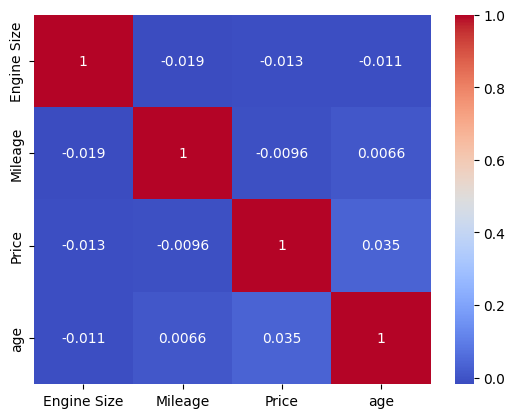

In [161]:
# # 6. Correlation matrix
# correlation_matrix = df.corr()
# print(correlation_matrix)
correlation_matrix = df.corr(numeric_only=True)

# plotting the correlation matrix using seaborn
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

<div style="border: 4px solid #f59e0b; padding: 10px 12px; background: #1f2933; margin: 10px 0; text-align: left; border-radius: 10px;">
  <h2 style="color: #f9fafb; margin: 0 0 8px 0; font-size: 2em; letter-spacing: 3px;">
    🔍 OBSERVATION:
  </h2>

  <ul style="margin: 0 0 12px 18px; padding:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    <li>The dataset has <b>2,500 rows</b> and <b>10 columns</b>. Many columns are numeric, so splitting into <b>X</b> and <b>y</b> is straightforward.</li>
    <li>I removed <b>Car ID</b> and <b>Model</b>:
      <ul style="margin: 6px 0 0 18px; padding:0; color:#e5e7eb;">
        <li><b>Car ID</b> is just an identifier, so it does not help predict price.</li>
        <li><b>Model</b> has <b>28 categories</b>, which adds too many extra variables for the size of this dataset.</li>
      </ul>
    </li>
    <li>I cleaned missing values (null/empty cells). This matters because missing data can confuse the model during training.</li>
 
  </ul>

  <p style="margin: 0 0 10px 0; color:#fde68a; font-size:16px; line-height:1.5;">
    <b>Feature drop test (R² change):</b> I dropped one column at a time and checked how much the R-squared score changed.
    A negative value means the model performed worse after removing that feature, so the feature is useful.
  </p>

  <ul style="margin: 0 0 10px 18px; padding:0; color:#fde68a; font-size:16px; line-height:1.6;">
    <li><b>Drop Mileage</b> → R² change: <b>-0.05</b></li>
    <li><b>Drop Year</b> → R² change: <b>-0.05</b></li>
    <li><b>Drop Condition</b> → R² change: <b>-0.03</b></li>
    <li><b>Drop Engine Size</b> → R² change: <b>-0.02</b></li>
    <li><b>Drop Brand</b> → R² change: <b>-0.02</b></li>
    <li><b>Drop Fuel Type</b> → R² change: <b>-0.02</b></li>
    <li><b>Drop Transmission</b> → R² change: <b>-0.02</b></li>
  </ul>

  <p style="margin: 0; color:#e5e7eb; font-size:16px; line-height:1.5;">
    From this quick test, <b>Mileage</b> and <b>Year</b> seem to be the most important features because removing them caused
    the biggest performance drop.
  </p>
</div>


---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #f59e0b; width: fit-content;">

<h2 style="margin:0; color:#f9fafb;">
<b>Data Preparation</b>
</h2>
</div>


<h3>
<strong style='color:orange ;'>Case 1: Binary variables (only two options)
 </strong>
</h3>




In [162]:
# this just converts the value of column to 0 or 1
# factorize in pandas works too, but only one column at a time

from sklearn.preprocessing import LabelEncoder
variables = ['Transmission']
encoder = LabelEncoder()
df[variables] = df[variables].apply(encoder.fit_transform)

<h3>
<strong style='color:orange ;'>Case 2: Ordinal variables (categories that have an order/rank -> can be compared)
</strong>
</h3>




In [163]:
# variable 1: cut

cut_mapping = {"New": 3, "Used": 1, "Like New": 2}
df['Condition'] = df['Condition'].map(cut_mapping)

<h3 style='color:orange'>
  <b>Case 3: Nominal categories (categories that can't be compared numerically)</b>
</h3>

In [164]:
# Nominal categories
# this makes multiple columns with the variable (Separate for yes/no)
# Not using year and milage beacause 
from sklearn.preprocessing import OneHotEncoder
variables = ["Brand", 'Fuel Type']

# using encoder

encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
one_hot_encoded = encoder.fit_transform(df[variables]).astype(int)
df = pd.concat([df,one_hot_encoded],axis=1).drop(columns=variables)

<div style="border: 4px solid #f59e0b; padding: 5px; background: #1f2933; margin: 5px 0; text-align: left;">
  <h2 style="color: #f9fafb; margin: 0; font-size: 2em; letter-spacing: 3px;">
    🔍 OBSERVATION:
  </h2 >

    For the first case, I changed the transmission column into a binary variable. Since it only had two options, using 0s and 1s works best.

    In the second case, I gave the car conditions a score. I set "new" as 3, "like new" as 2, and "used" as 1.

    Lastly in the third case, I fixed the categories for engine size, brand, and fuel type. I transformed those so the computer can actually read them as labels.
</div>


---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #f59e0b; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b> STEP 3: X/y and train/test -split</b>
</h3>
</div>


<h3 style='color:orange'>
  <b>Data preparation as X and Y</b>
</h3>


In [165]:
# first step, we split our data into SUPPORT variables and the TARGET variable
# X => support variables, y => target variable

# X => list of support variables the model uses 
# while predicting the target variable with the model
X = df.drop("Price", axis=1)

# our target variable is y
y = df['Price']

<h3 style='color:orange'>
  <b>Data is good to go (all numbers) => train model etc.
</b>
</h3>


In [166]:
# secondly, train/test -split with scikit-learn's helper function
# 0.3 for testing => 30% of data is reserved for testing purposes
# and based on that => it's deduced that 70% will be in the training data

# you can also define the random state, which is sometimes useful
# if you want to "lock down" all the randomness in order to get same results every time
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

 <div style="background-color: #e7f3ff; border-left: 5px solid #2196F3; padding: 15px; margin: 20px 0; border-radius: 5px;">
    <h3 style="color: #1976D2; margin-top: 0;">🔑 Key Insight: Training the X and the y split</h3>
    <p style="color: #1565C0;">
        
        I have used the 30 70 split for this model
</div>

---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #f59e0b; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b>STEP 4: Create and train the ML model</b>
</h3>
</div>


In [167]:
# create the model and train it with the data

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [168]:
# model = RandomForestRegressor(random_state=42).fit(X_train, y_train)
# model

 <div style="background-color: #e7f3ff; border-left: 5px solid #2196F3; padding: 15px; margin: 20px 0; border-radius: 5px;">
    <h3 style="color: #1976D2; margin-top: 0;">🔑 Key Insight: Random Forest Regression  </h3>
    <p style="color: #1565C0;">
        
    I have used Random Forest Regression to check if can we use it instead of linear Regression to make a workable ML model.
</div>

In [169]:
# we need to create test predictions based on our earlier reserved test dataset
# this data has never been seen by the model by now
predictions = model.predict(X_test)

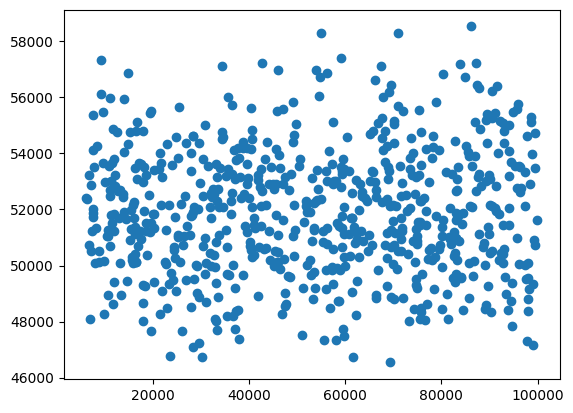

In [170]:
# let's plot how far the predictions are from the real target values (y)
# in the test dataset

# if the values follow a diagonal line (from bottom left to top right)
# => we have good predictions with the model
# we basically compare the predicted values to the actual true values 
# and compare the differences

plt.scatter(y_test, predictions)
plt.show()

<div style="border: 4px solid #f59e0b; padding: 5px; background: #1f2933; margin: 5px 0; text-align: left;">
  <h2 style="color: #f9fafb; margin: 0; font-size: 2em; letter-spacing: 3px;">
    🔍 OBSERVATION:
  </h2>

    The scatter plot reveals poor model performance
  <i style='color:#fde68a; background-color:#111827;'> In an ideal model, points should follow a diagonal line indicating accurate predictions. </i>

</div>


<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #f59e0b; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b> STEP 5: Error and performance metrics</b>
</h3>
</div>


In [171]:
# MAE = Mean average error
mae = metrics.mean_absolute_error(y_test, predictions)
print("MAE:")
print(f"{round(mae, 2)} $")

# MSE = Mean squared error
mse = metrics.mean_squared_error(y_test, predictions)
print("\nMSE:")
print(f"{round(mse, 2)} $^2")

# RMSE = Root Mean Squared Error
rmse = np.sqrt(mse)
print("\nRMSE:")
print(f"{round(rmse, 2)} $")

# R-square (or R2) - how well the model describes the original dataset
# 1 => model describes the data perfectly
# 0 => model doesn't describe the data at all
r2 = metrics.r2_score(y_test, predictions)
print("\nR-squared:")
print(f"{round(r2, 2)}")


MAE:
23593.91 $

MSE:
735331547.52 $^2

RMSE:
27117.0 $

R-squared:
-0.01


/var/folders/yy/4vrmj46n0_53mpnmp8clw2fh0000gn/T/ipykernel_13562/2665833334.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_test - predictions))


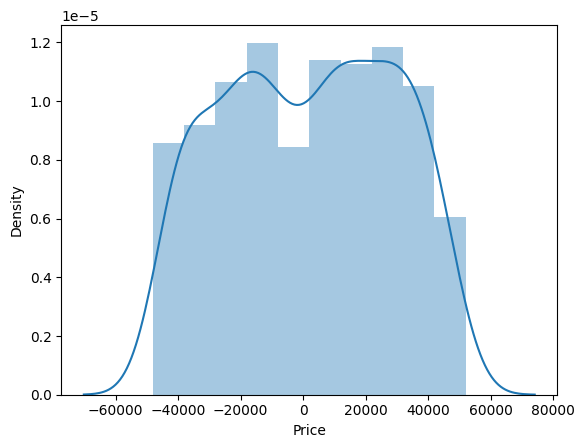

In [172]:
# if the prediction distribution is far from standard normal distritbuion
# then the model is not probably good enough
# distplot is deprecated and will be removed in future seaborn versions
# but not direct replacement has been created so far

sns.distplot((y_test - predictions))
plt.show()
plt.close()

In [173]:
X.columns

Index(['Engine Size', 'Transmission', 'Mileage', 'Condition', 'age',
       'Brand_Audi', 'Brand_BMW', 'Brand_Ford', 'Brand_Honda',
       'Brand_Mercedes', 'Brand_Tesla', 'Brand_Toyota', 'Fuel Type_Diesel',
       'Fuel Type_Electric', 'Fuel Type_Hybrid', 'Fuel Type_Petrol'],
      dtype='object')

<div style="border: 4px solid #f59e0b; padding: 5px; background: #1f2933; margin: 5px 0; text-align: left;">
  <h2 style="color: #f9fafb; margin: 0; font-size: 2em; letter-spacing: 3px;">
    🔍 OBSERVATION:
  </h2>

  <i style="color:#fde68a; background-color:#111827;"> 
    R-squared: -0.01<br/><br/>
    The R-squared is -0.01, which is very weak. Normally, this value is between 0 and 1. Since it’s negative, the model is
    doing worse than a simple baseline that predicts the average price for every car. That means the model is not fitting
    the data well.
  </i>

</div>


---

In [174]:
df

,Engine Size,Transmission,Mileage,Condition,Price,age,Brand_Audi,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Mercedes,Brand_Tesla,Brand_Toyota,Fuel Type_Diesel,Fuel Type_Electric,Fuel Type_Hybrid,Fuel Type_Petrol
0,2.3,1,114832.0,3,26613.92,10.0,0,0,0,0,0,1,0,0,0,0,1
1,4.4,1,143190.0,1,14679.61,8.0,0,1,0,0,0,0,0,0,1,0,0
2,4.5,1,181601.0,3,44402.61,13.0,1,0,0,0,0,0,0,0,1,0,0
3,4.1,0,68682.0,3,86374.33,15.0,0,0,0,0,0,1,0,1,0,0,0
4,2.6,1,223009.0,2,73577.10,17.0,0,0,1,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2494,2.3,1,162586.0,1,90378.98,25.0,0,0,0,0,1,0,0,0,0,0,1
2495,2.4,0,22650.0,2,61384.10,6.0,1,0,0,0,0,0,0,0,0,0,1
2496,5.7,1,77701.0,2,24710.35,25.0,1,0,0,0,0,0,0,0,0,1,0
2498,4.5,1,229164.0,2,46085.67,24.0,1,0,0,0,0,0,0,1,0,0,0


<h3 style='color:orange'>
  <b>Using the model in practice
</b>
</h3>

In [175]:
df.columns.tolist()

['Engine Size',
 'Transmission',
 'Mileage',
 'Condition',
 'Price',
 'age',
 'Brand_Audi',
 'Brand_BMW',
 'Brand_Ford',
 'Brand_Honda',
 'Brand_Mercedes',
 'Brand_Tesla',
 'Brand_Toyota',
 'Fuel Type_Diesel',
 'Fuel Type_Electric',
 'Fuel Type_Hybrid',
 'Fuel Type_Petrol']

In [176]:
# usually in GUI application we save the model-object / variable into a file (by using joblib-module)
# and in the GUI application => we load the saved model from the file
# and use the model just like here below

# this variable could be connected to a user interface (textbox, slider etc.)

# map all the variables from the user
# into a Python dictionary
# the variable names have to match with the original dataset

tester_row = {

    'Engine Size' : '2.3',
    'Transmission' : '2',
    'Mileage' : '100000',
    'Condition' : '2',
    'age' : '14',
    'Brand_Audi' : '0',
    'Brand_BMW' : '0',
    'Brand_Ford' : '0',
    'Brand_Honda' : '0',
    'Brand_Mercedes' : '0',
    'Brand_Tesla' : '0',
    'Brand_Toyota' : '1',
    'Fuel Type_Diesel' : '0',
    'Fuel Type_Electric' : '0',
    'Fuel Type_Hybrid' : '0',
    'Fuel Type_Petrol' : '1'

}

# convert to pandas format
tester_row = pd.DataFrame([tester_row])

In [ ]:
# get the output/result from the model
# based on the user's given new data (above code cell)
# we drop the price column because it's the target variable and we want to predict it

result = model.predict(input_row)[0]

print()
print("Predicted car price for the new input:")
print(f"$ {round(float(result), 2)}")
print("----------------------------")


Predicted car price for the new input:
$ 51900.87
----------------------------


---


<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #f59e0b; width: fit-content;">

<h1 style="margin:0; color:#f9fafb;">
<b>Conclusion</b>
</h1>
</div>


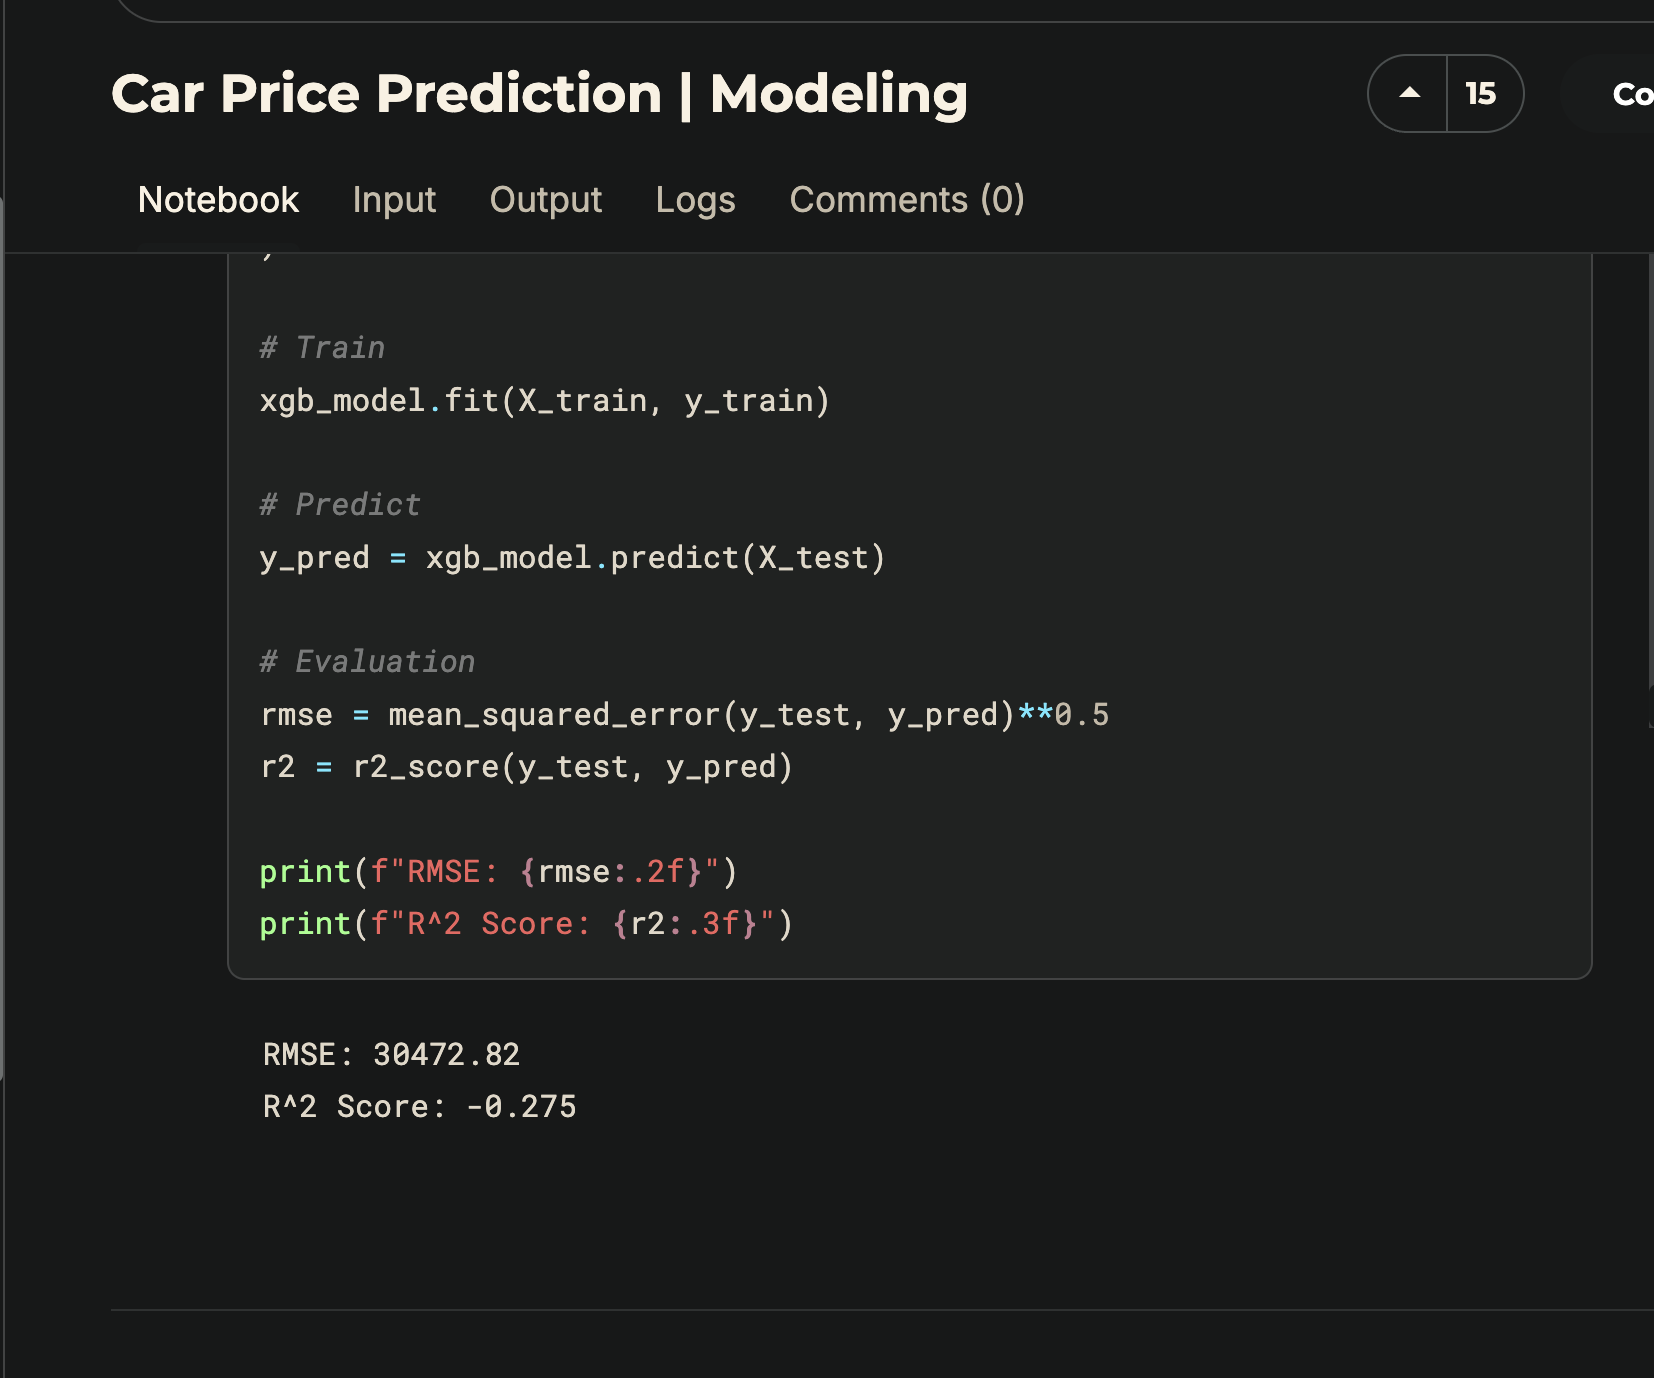

<div style="border: 4px solid #f59e0b; padding: 10px 12px; background: #1f2933; margin: 20px 0; text-align: left; border-radius: 10px;">
  <h2 style="color: #f9fafb; margin: 0 0 8px 0; font-size: 2em; letter-spacing: 2px;">
    🔍 CONCLUSION
  </h2>

  <p style="margin: 0 0 10px 0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    This model did not perform well on the test data. The error is high, and the R-squared is negative.
    That means it is doing worse than a simple baseline that predicts the average car price every time.
  </p>

  <p style="margin: 0 0 10px 0; color:#fde68a; font-size:16px; line-height:1.6;">
    <b>Results:</b><br/>
    RMSE: <b>30472.82 (from the picture above)</b><br/>
    R² Score: <b>-0.275 (from the picture above)</b>
  </p>

  <p style="margin: 0 0 10px 0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    So right now, this is not ready for real use. It did not learn the price pattern well.
    The data may need better feature work, or a different model setup.
  </p>

  <ul style="margin: 0 0 0 18px; padding:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    <li>Get more data if possible.</li>
  </ul>
</div>
